In [12]:
#7.1
import numpy as np
from numpy import linalg as la


A = np.array([1,2, 3,0,-4,1,0,3,-1]).reshape(3,3)
print("A=")
print(A)


det = la.det(A)
print(f"det A= {det}")

b= np.array([2,2,-1])
Ainv=la.inv(A)
xyz=Ainv@b

print(f"xyz={xyz}")

is_orth = np.array_equal(A.T, la.inv(A))     #if orth then A.T = inv(A) np.array_equal evaluates if matrices equal
print(f" Is orthogonal? {is_orth}")

Lambda, v = la.eig(A)
print("Lambda = ", Lambda)
#print(f"\nEigenvectors:\n{v}")   <-- if eigen vector

A=
[[ 1  2  3]
 [ 0 -4  1]
 [ 0  3 -1]]
det A= 1.0
xyz=[10. -1. -2.]
 Is orthogonal? False
Lambda =  [ 1.         -4.79128785 -0.20871215]


In [30]:
#7.3
import numpy as np
from numpy import linalg as la


E=np.array([-0.06698874, -0.87275577, -0.48353891, 0.49272847, -0.45034696,  0.74458463, -0.86760081, -0.1883746, 0.46019978]).reshape(3,3)

print(E)


detE= la.det(E)
print(f"the matrix E is rotational since the determinant is {detE}")             #transpose
print()

Lambda, vect = la.eig(E)           
print("Lambda = ", Lambda)
print(f"\nEigenvectors:\n{vect}") 



alpha=192.25
delta=27.4

r=np.array([np.cos(alpha)*np.cos(delta), np.cos(delta)*np.sin(alpha), np.sin(delta) ]).reshape(3,1)

v = [-0.86760081, -0.1883746, 0.46019978]

L = la.norm(v)
print()
print("norm of v is", L, "or approximatively 1")

v2= np.round(np.matmul(E,v))
print()
print(f"v2 is {v2} <--only z component")

[[-0.06698874 -0.87275577 -0.48353891]
 [ 0.49272847 -0.45034696  0.74458463]
 [-0.86760081 -0.1883746   0.46019978]]
the matrix E is rotational since the determinant is 0.9999999982754761

Lambda =  [-0.52856796+0.84889099j -0.52856796-0.84889099j  0.99999999+0.j        ]

Eigenvectors:
[[ 0.09023842+0.58384315j  0.09023842-0.58384315j -0.54951651+0.j        ]
 [ 0.68877691+0.j          0.68877691-0.j          0.22621391+0.j        ]
 [-0.13207344+0.39890747j -0.13207344-0.39890747j  0.80427537+0.j        ]]

norm of v is 0.9999999964749322 or approximatively 1

v2 is [ 0. -0.  1.] <--only z component


m: [0.28866811]


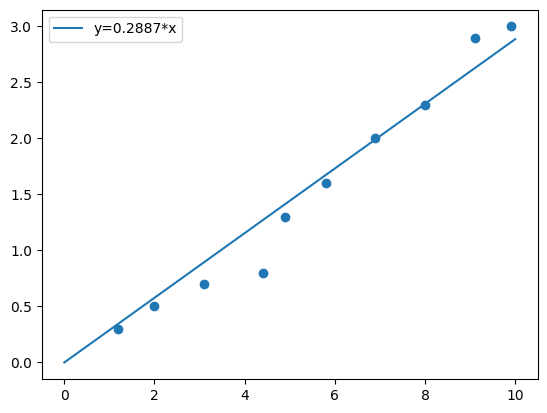

In [38]:
#7.5
import numpy as np
from numpy import linalg as la
from matplotlib.pyplot import show, figure
import matplotlib.pyplot as plt


x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])

plt.scatter(x,y)    #plotting scatter of data


# reshape for matrix operations (n, 1)       <--makes the array 2d so it can work for operations
X = x[:, np.newaxis] 


# (X^T * X) * slope = X^T * y
XTX = X.T @ X
XTy = X.T @ y

#find slope
m = np.linalg.solve(XTX, XTy)

print(f"m: {slope}")    #<--forced 0 intercept


x_=np.linspace(0,10)
y_ =m*x_      #making model to plot

plt.plot(x_,y_, label="y=0.2887*x")    #plotting the fit

plt.legend()

input X: 3
input type of interpolation: linear


expected y val for linear interpolation ; 0.6818181818181818


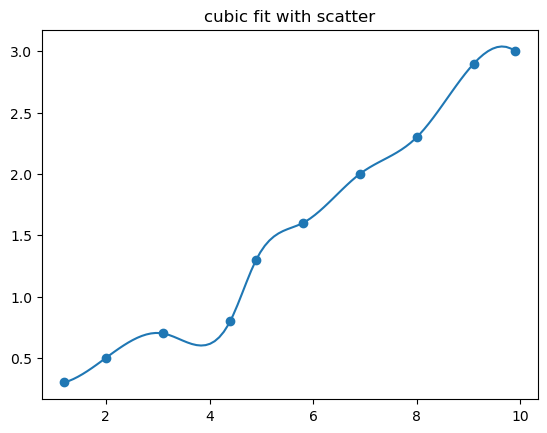

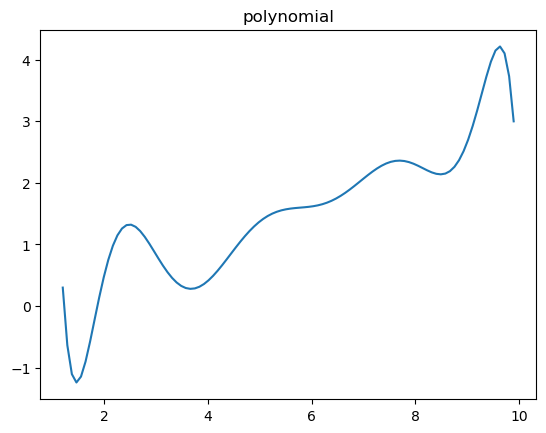

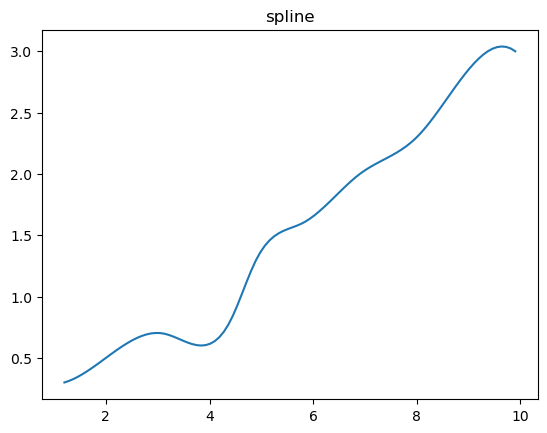

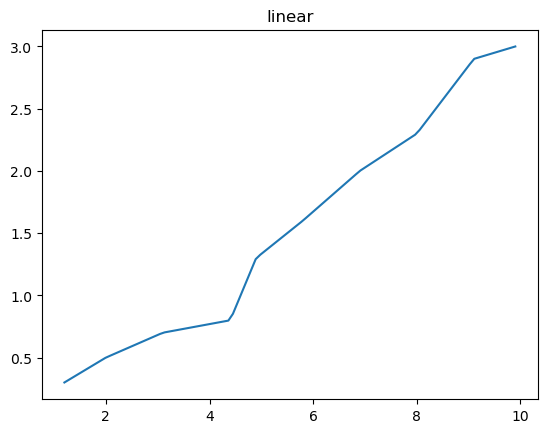

In [16]:
#7.6

import numpy as np
from numpy import linalg as la
from scipy import interpolate
from matplotlib.pyplot import show, figure
import matplotlib.pyplot as plt

x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])

x_=np.linspace(1.2,9.9,100)


f = interpolate.interp1d(x, y, kind='cubic')
new_y = f(x_)

fig, ax= plt.subplots()

ax.scatter(x,y)
ax.plot(x_, new_y)
ax.set_title("cubic fit with scatter")

#compared to 7.5 it goes through all the points, seems alot more precise, allows for more complex fits

class interpolation():
    def __init__(self, x, y):
        self.x=x
        self.y=y
        
    def spline(self):             #cubic fit using interp1d
        f = interpolate.interp1d(x, y, kind='cubic')   
        x1=np.linspace(np.min(self.x), np.max(self.x),100)
        new_y = f(x1)

        fig1, ax1= plt.subplots()
        ax1.plot(x1, new_y)
        ax1.set_title("spline")

    def linear(self):                          #linear fit using interp1d
        f = interpolate.interp1d(x, y, kind='linear')
        x2=np.linspace(np.min(self.x), np.max(self.x),100)
        new_y = f(x2)

        fig2, ax2= plt.subplots()
        ax2.plot(x2, new_y)
        ax2.set_title("linear")

    def polynomial(self):           #polynomial to the degree of n-1
        coeffs=np.polyfit(self.x, self.y, len(self.x) -1)    #finds coefficients (degree=n-1)
        x3=np.linspace(np.min(self.x), np.max(self.x),100)
        new_y=np.polyval(coeffs, x3)

        
        fig3, ax3= plt.subplots()
        ax3.plot(x3, new_y)
        ax3.set_title("polynomial")

    def prediction(self, X, type_):
        if (np.min(self.x)<=X<=np.max(self.x)):
            if type_=='spline':
                f = scipy.interpolate.interp1d(self.x, self.y, kind='cubic')
                return(f(X))
            elif type_=='linear':
                f = scipy.interpolate.interp1d(self.x, self.y, kind='linear')
                return(f(X))
            elif type_=='polynomial':
                coeffs=np.polyfit(self.x, self.y, len(self.x) -1)    #finds coefficients (degree=n-1)
                new_y=np.polyval(coeffs, X)
                return(new_y)
            
        else:
            print(f"X out of range.")



    
U=interpolation(x, y)
U.polynomial()
U.spline()
U.linear()

X = float(input("input X:"))
type_ = input("input type of interpolation:")

result = U.prediction(X, type_)




print(f"expected y val for {type_} interpolation ; {result}")

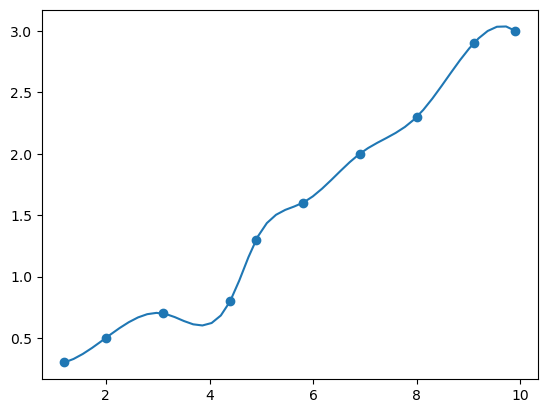

Input a value for X hat: 3


TypeError: 'numpy.ndarray' object is not callable

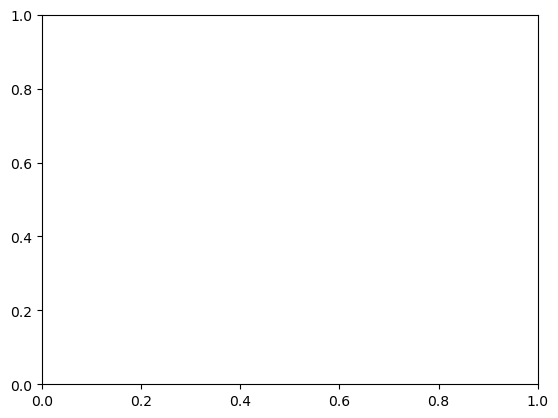

In [5]:
import numpy as np
from numpy import linalg as la
import scipy
import matplotlib.pyplot as plt

x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])

f = scipy.interpolate.interp1d(x, y, kind='cubic') #using interp1d
newx = np.linspace(1.2, 9.9) #defining a new x range
newy = f(newx)

fig, ax= plt.subplots()
ax.scatter(x,y)
ax.plot(newx, newy)
plt.show()

X=float(input("Input a value for X hat:"))

class interpolation():
    def __init__(self, x, y):
        self.x=x
        self.y=y

    def spline(self):
        fig2, ax2= plt.subplots()
        f = scipy.interpolate.interp1d(self.x, self.y, kind='cubic') #using interp1d
        newx = np.linspace(np.min(self.x), np.max(self.x), len(self.x)*100) #defining a new x range
        newy = f(newx)
        ax2.plot(newx, newy)

    def polynomial(self):
        fig3, ax3= plt.subplots()
        A=[]
        n = len(self.x)
        for i in range(n): #creating the matrix
            for j in reversed(range(n)):
                row = self.x[i]**j 
                A.append(row)
        
        Amat=np.array(A).reshape(n,n) 
        y2=self.y.reshape(len(self.y), 1)

        sol=la.solve(Amat, y2) 

        newx=np.linspace(np.min(self.x),np.max(self.x), len(self.x)*100)

        newy=0
        for i in range(len(sol)):
            newy=newy+sol[i](newx*(len(self.x)-1-i)) 
        ax3.plot(newx, newy)

    def linear(self):
        fig4, ax4= plt.subplots()
        f = scipy.interpolate.interp1d(self.x, self.y, kind='linear') #using interp1d
        newx = np.linspace(np.min(self.x), np.max(self.x), len(self.x)*100) #defining a new x range
        newy = f(newx)
        ax4.plot(newx, newy)

    def x_hat(self, X, interp):
        if np.min(self.x)<= X <=np.max(self.x):
            if interp =='spline':
                f = scipy.interpolate.interp1d(self.x, self.y, kind='cubic')
                y=f(X)
                return y
            elif interp=='polynomial':
                A=[]
                n = len(self.x)
                for i in range(n): #creating the matrix
                    for j in reversed(range(n)):
                        row = self.x[i]**j 
                        A.append(row)
        
                Amat=np.array(A).reshape(n,n) #what the flip
                y2=self.y.reshape(len(self.y), 1)

                sol=la.solve(Amat, y2) 

                newx=np.linspace(np.min(self.x),np.max(self.x), len(self.x)*100)

                newy=0
                for i in range(len(sol)):
                    newy=newy+sol[i](X*(len(self.x)-1-i))
                return newy
                
            elif interp=='linear':
                f = scipy.interpolate.interp1d(self.x, self.y, kind='linear')
                y=f(X)
                return y
            else:
                print("X is not in range")
U=interpolation(x, y)
U.polynomial()
U.spline()
U.linear()
uxl=U.x_hat(X, 'linear')
uxp=U.x_hat(X, 'polynomial')
uxs=U.x_hat(X, 'spline')
print(uxl)
print(uxp)
print(uxs)

In [3]:
#7.7
import numpy as np


def bilinearIP(I, col, row): # Make it X, Y compatible
    '''I is a two dimensional array and iF,jF is the position at
       which we want to interpolate. 'iF' must be bigger or equal to 0 and
       smaller than the highest index of I in i. The same applies for jF'''
    rowlen, collen= I.shape
    i = int(row)
    j = int(col)
    if row - i == 0 and col - j == 0:  # Falls exactly on a gridpoint
        return I[i,j]

    inbounds = (0 <= j <= collen-1) and (0 <= i <= rowlen-1)
    if not inbounds:
        Iintp = None
    else:
        mu =  row - i
        Lambda = col - j
        # If we are at the last pixel at the right or bottom, then there
        # is not a neighbour, so we take the pixel itself as the neighbour
        I0 = I[i,j]
        I1 = I[i,min(j+1,collen-1)]
        I2 = I[min(i+1,rowlen-1),j]
        I3 = I[min(i+1,rowlen-1),min(j+1,collen-1)]
        Iintp = (1-Lambda)*(1-mu)*I0 + Lambda*(1-mu)*I1 + mu*(1-Lambda)*I2 + Lambda*mu*I3
    return(Iintp)

I = np.array([[2.0,4.1], [2.5,3.8]])

row_y = 0.7 # Row position is y value
col_x = 0.2  # Column position is x value

Iintp = bilinearIP(I, col_x, row_y)
if Iintp:
    print(f"The interpolated intensity at (i,j) = {row_y},{col_x} => (x, y) = {col_x},{row_y} is {Iintp:.6f}")
else:
    print("One of the indices was outside the limits")



The interpolated intensity at (i,j) = 0.7,0.2 => (x, y) = 0.2,0.7 is 2.658000


Intercept beta0=9.189492762451197, slope beta1=71.3829624600685


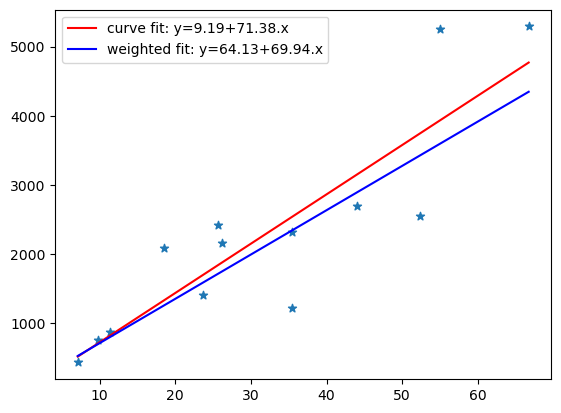

In [18]:
#7.10
import matplotlib.pyplot as plt
import numpy as np
import scipy 


#scipy.optimize.leastsq()
#scipy.optimize.curve_fit()


data = [
   18.49,     2094.75,    0.3,           100,
   35.48,     2320.87,    2.2,           120,
   35.48,     1224.9,     3.0,           80,
   11.34,     872.13,     1.2,           80,
   7.12,      432.2,      0.4,           70,
   9.82,      751,        0.3,           75,
   23.66,     1410,       2.3,           70,
   44,        2700,       4.0,           110,
   66.7,      5292,       5.3,           120,
   52.4,      2550,       5.2,           100,
   55,        5253,       6.1,           150,
   25.6,      2419,       3.2,           110,
   26.19,     2158,       2.8,           110
]

data_n = np.array(data).reshape(13,4)   #reshaping data so its usuable

d_Mpc = data_n[:,0]
v_kms=data_n[:,1]
d_er = data_n[:,2]
v_er=data_n[:,3]   #defining data

D = np.linspace(np.min(d_Mpc), np.max(d_Mpc), 50) #create range for the model fits 


def model(x, beta0, beta1):     #simple linear relation y=m*x+c
    """The model with parameters a and b. Note that for the Hubble relation we fix a to 0.0"""
    return beta0 + beta1*x

beta, pcov = scipy.optimize.curve_fit(model, d_Mpc, v_kms)

Y=model(D, beta[0], beta[1])

print(f"Intercept beta0={beta[0]}, slope beta1={beta[1]}")




# define model and res fct
def residuals(p, x, y, sigy):
        slope, intercept = p
        modell=slope*x + intercept
        return ((y - modell)/sigy)        #weighting error   (deviding by error means large error is weighed less and small error weighed more)

p0 = [1,0]    #initial guess
p_lsq= scipy.optimize.leastsq(residuals, p0, args=(d_Mpc, v_kms, v_er))
m, c = p_lsq[0]




plt.scatter(d_Mpc, v_kms, marker='*')
plt.plot(D,Y, label=f'curve fit: y={beta[0]:.2f}+{beta[1]:.2f}.x', color='r')
plt.plot(D, m*D+c, label=f"weighted fit: y={m:.2f}+{c:.2f}.x", color='b')
plt.legend()


In [ ]:
#7.14

